In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("traffic_density_202501.csv", sep=',', quotechar='"')
df.columns = df.columns.str.strip().str.replace('"', '')

In [3]:
import pandas as pd
import numpy as np
# Alet çantamızdan motoru ve güncel fikstürü çağırıyoruz
from utils import calculate_haversine_distance, df_fixtures

print("Zaman sütunları optimize ediliyor ve maç bölgeleri taranıyor...")

# 1. Hazırlık (Zaman dönüşümlerini TEK SEFERDE yapıyoruz)
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df['date_only'] = df['DATE_TIME'].dt.date

# 2. İlklendirme
df['is_match_zone'] = 0
RADIUS_KM = 3.0 

# 3. Uzamsal ve Zamansal Vektörel Tarama
for _, match in df_fixtures.iterrows():
    # Gün ve Saat filtreleme (Vektörel Maske)
    date_mask = (df['date_only'] == match['match_date'])
    time_mask = (df['DATE_TIME'] >= match['effect_start']) & (df['DATE_TIME'] <= match['effect_end'])
    
    potential_traffic_idx = df[date_mask & time_mask].index
    
    if len(potential_traffic_idx) > 0:
        # Sadece potansiyel adaylar için gerçek Haversine mesafesini hesapla
        distances = calculate_haversine_distance(
            df.loc[potential_traffic_idx, 'LATITUDE'],
            df.loc[potential_traffic_idx, 'LONGITUDE'],
            match['lat'],
            match['lon']
        )
        
        # 3km yarıçap kontrolü
        distance_mask = (distances <= RADIUS_KM)
        final_match_idx = potential_traffic_idx[distance_mask]
        
        # İşaretleme
        df.loc[final_match_idx, 'is_match_zone'] = 1

print(f"İşlem Tamamlandı. İşaretlenen maç trafiği satır sayısı: {df['is_match_zone'].sum()}")

Zaman sütunları optimize ediliyor ve maç bölgeleri taranıyor...
İşlem Tamamlandı. İşaretlenen maç trafiği satır sayısı: 2537


In [4]:
print(df_fixtures['match_date'].head(3))

0    2025-01-04
1    2025-01-08
2    2025-01-21
Name: match_date, dtype: object


In [5]:
df.head()

,DATE_TIME,LATITUDE,LONGITUDE,GEOHASH,MINIMUM_SPEED,MAXIMUM_SPEED,AVERAGE_SPEED,NUMBER_OF_VEHICLES,date_only,is_match_zone
0,2025-01-01,41.157532,28.888550,sxkd1k,58,107,79,11,2025-01-01,0
1,2025-01-01,41.003723,29.306030,sxkc6b,62,104,81,19,2025-01-01,0
2,2025-01-01,41.009216,29.295044,sxkc69,77,103,88,7,2025-01-01,0
3,2025-01-01,41.003723,29.295044,sxkc68,64,110,85,19,2025-01-01,0
4,2025-01-01,41.020203,29.273071,sxkc65,56,127,90,73,2025-01-01,0


In [6]:
df.sample(15)

,DATE_TIME,LATITUDE,LONGITUDE,GEOHASH,MINIMUM_SPEED,MAXIMUM_SPEED,AVERAGE_SPEED,NUMBER_OF_VEHICLES,date_only,is_match_zone
1055565,2025-01-19 13:00:00,41.113586,29.020386,sxk9uk,10,87,54,84,2025-01-19,0
1751980,2025-01-31 18:00:00,41.146545,29.492798,sxkfp4,75,106,92,9,2025-01-31,0
1332316,2025-01-24 09:00:00,40.937805,29.119263,sxk8ys,3,91,37,100,2025-01-24,0
297077,2025-01-06 05:00:00,41.003723,29.108276,sxk9q2,4,145,49,95,2025-01-06,0
730418,2025-01-13 20:00:00,41.119080,29.075317,sxk9vt,2,34,22,6,2025-01-13,0
135492,2025-01-03 09:00:00,41.086121,28.987427,sxk9ex,3,77,22,195,2025-01-03,0
790537,2025-01-14 21:00:00,41.075134,29.020386,sxk9sm,4,85,34,189,2025-01-14,0
1236177,2025-01-22 17:00:00,41.086121,29.064331,sxk9tr,6,71,34,15,2025-01-22,0
1427962,2025-01-26 02:00:00,41.014709,28.679810,sxk3kd,47,132,80,59,2025-01-26,0
1139845,2025-01-21 00:00:00,41.069641,28.811646,sxk3xs,3,131,78,248,2025-01-21,0


In [7]:
df.tail()

,DATE_TIME,LATITUDE,LONGITUDE,GEOHASH,MINIMUM_SPEED,MAXIMUM_SPEED,AVERAGE_SPEED,NUMBER_OF_VEHICLES,date_only,is_match_zone
1763958,2025-01-31 23:00:00,41.003723,28.888550,sxk932,2,125,40,270,2025-01-31,0
1763959,2025-01-31 23:00:00,41.009216,28.877563,sxk931,5,71,32,82,2025-01-31,0
1763960,2025-01-31 23:00:00,41.003723,28.877563,sxk930,1,71,32,73,2025-01-31,0
1763961,2025-01-31 23:00:00,41.042175,28.866577,sxk92z,4,56,19,66,2025-01-31,0
1763962,2025-01-31 23:00:00,41.036682,28.866577,sxk92y,3,49,20,60,2025-01-31,0


In [8]:
df.isnull().sum()

DATE_TIME             0
LATITUDE              0
LONGITUDE             0
GEOHASH               0
MINIMUM_SPEED         0
MAXIMUM_SPEED         0
AVERAGE_SPEED         0
NUMBER_OF_VEHICLES    0
date_only             0
is_match_zone         0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1763963 entries, 0 to 1763962
Data columns (total 10 columns):
 #   Column              Dtype         
---  ------              -----         
 0   DATE_TIME           datetime64[ns]
 1   LATITUDE            float64       
 2   LONGITUDE           float64       
 3   GEOHASH             object        
 4   MINIMUM_SPEED       int64         
 5   MAXIMUM_SPEED       int64         
 6   AVERAGE_SPEED       int64         
 7   NUMBER_OF_VEHICLES  int64         
 8   date_only           object        
 9   is_match_zone       int64         
dtypes: datetime64[ns](1), float64(2), int64(5), object(2)
memory usage: 134.6+ MB


Aykırı değer (Outlier) röntgeni çekiliyor...


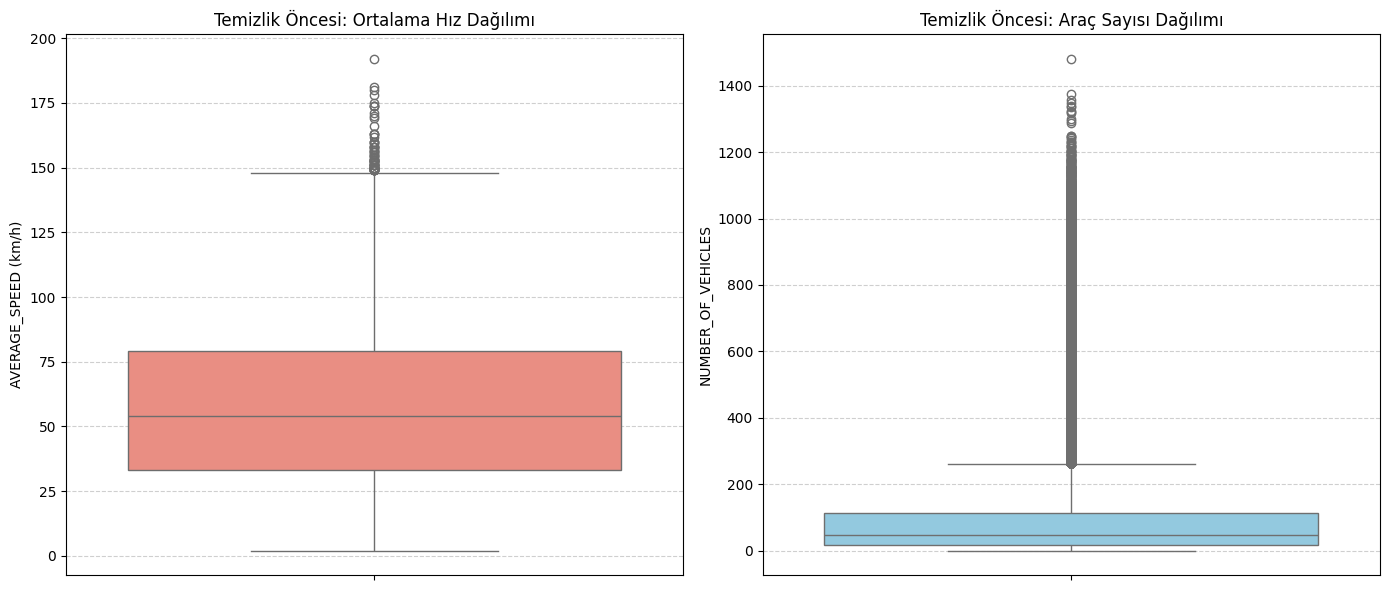

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Aykırı değer (Outlier) röntgeni çekiliyor...")

# Yan yana iki grafik göstermek için figür alanı açıyoruz
plt.figure(figsize=(14, 6))

# 1. Ortalama Hız Boxplot'u
plt.subplot(1, 2, 1)
# Kutu grafiği (Boxplot) verinin %50'sini kutu içine alır, dışarıda kalan noktalar aykırı değerlerdir
sns.boxplot(y=df['AVERAGE_SPEED'], color='salmon')
plt.title('Temizlik Öncesi: Ortalama Hız Dağılımı', fontsize=12)
plt.ylabel('AVERAGE_SPEED (km/h)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6, axis='y')

# 2. Araç Sayısı Boxplot'u
plt.subplot(1, 2, 2)
sns.boxplot(y=df['NUMBER_OF_VEHICLES'], color='skyblue')
plt.title('Temizlik Öncesi: Araç Sayısı Dağılımı', fontsize=12)
plt.ylabel('NUMBER_OF_VEHICLES', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6, axis='y')

plt.tight_layout()
plt.show()

In [11]:
print(f"Filtreleme öncesi veri sayısı: {len(df)}")

# 1. Mantıksız Hız Sınırları Filtresi
df = df[(df['MINIMUM_SPEED'] >= 0) & (df['MAXIMUM_SPEED'] <= 150)]

# 2. Araç Sayısı Sınırı (Negatif değer temizlği)
df = df[df['NUMBER_OF_VEHICLES'] >= 0]

# 3. Ortalama Hızın Tutarlılık Kontrolü
# Ortalama hız, Min ve Max değerlerin arasında olmak zorundadır.
df = df[(df['AVERAGE_SPEED'] >= df['MINIMUM_SPEED']) & (df['AVERAGE_SPEED'] <= df['MAXIMUM_SPEED'])]

print(f"Aykırı değerler temizlendikten sonraki veri sayısı: {len(df)}")

# 4. Veri sızıntısını önlemek için siliyoruz.
df.drop(columns=['MINIMUM_SPEED', 'MAXIMUM_SPEED'], inplace=True)
df.drop(columns=['GEOHASH'], inplace=True, errors='ignore')

print("Kritik Temizlik Yapıldı. Kalan Sütünlar:")
print(df.columns.tolist())

Filtreleme öncesi veri sayısı: 1763963
Aykırı değerler temizlendikten sonraki veri sayısı: 1617290
Kritik Temizlik Yapıldı. Kalan Sütünlar:
['DATE_TIME', 'LATITUDE', 'LONGITUDE', 'AVERAGE_SPEED', 'NUMBER_OF_VEHICLES', 'date_only', 'is_match_zone']


In [12]:
df["DATE_TIME"].head()

0   2025-01-01
1   2025-01-01
2   2025-01-01
3   2025-01-01
4   2025-01-01
Name: DATE_TIME, dtype: datetime64[ns]

In [13]:
# 1. Zamanı Parçalama
df['hour'] = df['DATE_TIME'].dt.hour
df['day_of_week'] = df['DATE_TIME'].dt.dayofweek  # 0: Pazartesi ... 6: Pazar

# 2. Döngüsel Saat (Cyclic Encoding)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# 3. Hafta Sonu Ayarlaması
# Cumartesi (5) ve Pazar (6) günlerini 1, diğer günleri 0 olarak kodluyoruz.
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x>=5 else 0)

# 4. Yılbaşı ve Sömestr Tarihlerini Ayarlama (Vektörel - Çok Hızlı)
# 1 Ocak Resmi Tatili Ayarlama
df['is_holiday'] = ((df['DATE_TIME'].dt.month == 1) & (df['DATE_TIME'].dt.day == 1)).astype(int)

# Sömestr Tatili Ayarlama (20-31 Ocak)
df['is_semester'] = ((df['DATE_TIME'].dt.month == 1) & (df['DATE_TIME'].dt.day >= 20) & (df['DATE_TIME'].dt.day <= 31)).astype(int)

print("Feature Engineering tamamlandı.")
print(df[['DATE_TIME', 'hour', 'hour_sin', 'is_weekend', 'is_holiday', 'is_semester']].tail())

Feature Engineering tamamlandı.
                  DATE_TIME  hour  hour_sin  is_weekend  is_holiday  \
1763958 2025-01-31 23:00:00    23 -0.258819           0           0   
1763959 2025-01-31 23:00:00    23 -0.258819           0           0   
1763960 2025-01-31 23:00:00    23 -0.258819           0           0   
1763961 2025-01-31 23:00:00    23 -0.258819           0           0   
1763962 2025-01-31 23:00:00    23 -0.258819           0           0   

         is_semester  
1763958            1  
1763959            1  
1763960            1  
1763961            1  
1763962            1  


In [14]:
df.sample(15)

,DATE_TIME,LATITUDE,LONGITUDE,AVERAGE_SPEED,NUMBER_OF_VEHICLES,date_only,is_match_zone,hour,day_of_week,hour_sin,hour_cos,is_weekend,is_holiday,is_semester
926799,2025-01-17 07:00:00,41.190491,29.031372,35,33,2025-01-17,0,7,4,9.659258e-01,-2.588190e-01,0,0,0
746191,2025-01-14 03:00:00,41.025696,28.602905,59,17,2025-01-14,0,3,1,7.071068e-01,7.071068e-01,0,0,0
1302621,2025-01-23 21:00:00,40.987244,29.141235,32,68,2025-01-23,0,21,3,-7.071068e-01,7.071068e-01,0,0,1
1552707,2025-01-28 07:00:00,41.014709,28.482056,72,26,2025-01-28,0,7,1,9.659258e-01,-2.588190e-01,0,0,1
1137427,2025-01-20 23:00:00,41.283875,28.624878,88,12,2025-01-20,0,23,0,-2.588190e-01,9.659258e-01,0,0,1
987229,2025-01-18 08:00:00,40.981750,28.767700,59,99,2025-01-18,0,8,5,8.660254e-01,-5.000000e-01,1,0,0
762684,2025-01-14 10:00:00,40.992737,29.130249,24,106,2025-01-14,0,10,1,5.000000e-01,-8.660254e-01,0,0,0
1238638,2025-01-22 18:00:00,41.036682,29.152222,53,215,2025-01-22,0,18,2,-1.000000e+00,-1.836970e-16,0,0,1
585132,2025-01-11 06:00:00,41.086121,28.031616,95,17,2025-01-11,0,6,5,1.000000e+00,6.123234e-17,1,0,0
577374,2025-01-11 03:00:00,41.179504,29.042358,42,1,2025-01-11,0,3,5,7.071068e-01,7.071068e-01,1,0,0


In [15]:
df['is_match_zone'].value_counts()

is_match_zone
0    1614769
1       2521
Name: count, dtype: int64

In [16]:
df.columns

Index(['DATE_TIME', 'LATITUDE', 'LONGITUDE', 'AVERAGE_SPEED',
       'NUMBER_OF_VEHICLES', 'date_only', 'is_match_zone', 'hour',
       'day_of_week', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday',
       'is_semester'],
      dtype='object')

In [17]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 12 Modelin Import Edilmesi
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

print("\n--- AŞAMA 4: MODELLER YARIŞIYOR ---")

# 1. Özellikler ve Hedef Seçimi (is_match_zone eklendi!)
features = ['LATITUDE', 'LONGITUDE', 'NUMBER_OF_VEHICLES', 
            'hour', 'hour_sin', 'hour_cos', 'day_of_week', 
            'is_weekend', 'is_holiday', 'is_semester', 'is_match_zone']

X = df[features]
y = df['AVERAGE_SPEED']

# Büyük veri olduğu için bilgisayarını kilitlememesi adına hızlı test için %5 örneklem (Benchmark)
# Hocana sunacağın asıl finalde bu kısmı kaldırıp tüm veriyi eğitebilirsin.
X_sampled = X.sample(frac=0.05, random_state=42)
y_sampled = y.loc[X_sampled.index]

# 2. Bölme ve Ölçeklendirme
X_train, X_test, y_train, y_test = train_test_split(X_sampled, y_sampled, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model Sözlüğü
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42)
}

# 4. Eğitim Döngüsü
results = []
print("Modeller yarışıyor, lütfen donanımınızın gücüne göre bekleyin...\n")

for name, model in models.items():
    print(f"{name} eğitiliyor...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results.append({
        "Model": name,
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
        "R2_Score": round(r2_score(y_test, y_pred), 3)
    })

# 5. Raporlama (Hata payı en düşük olandan en yükseğe doğru)
results_df = pd.DataFrame(results).sort_values(by='RMSE')
print("\n=== FINAL PERFORMANS RAPORU ===")
print(results_df.to_string(index=False))


--- AŞAMA 4: MODELLER YARIŞIYOR ---
Modeller yarışıyor, lütfen donanımınızın gücüne göre bekleyin...

Linear Regression eğitiliyor...
Ridge eğitiliyor...
Lasso eğitiliyor...
ElasticNet eğitiliyor...
KNN eğitiliyor...
SVR eğitiliyor...
Decision Tree eğitiliyor...
Random Forest eğitiliyor...
Extra Trees eğitiliyor...
AdaBoost eğitiliyor...
Gradient Boosting eğitiliyor...
XGBoost eğitiliyor...

=== FINAL PERFORMANS RAPORU ===
            Model   RMSE  R2_Score
      Extra Trees  7.196     0.913
    Random Forest  7.226     0.912
          XGBoost  8.779     0.871
    Decision Tree  9.756     0.840
Gradient Boosting 14.393     0.652
              KNN 16.087     0.565
              SVR 17.513     0.485
         AdaBoost 19.082     0.388
            Lasso 22.896     0.120
            Ridge 22.899     0.119
       ElasticNet 22.899     0.119
Linear Regression 22.899     0.119


C:\Users\ENES\AppData\Local\Temp\ipykernel_15584\3671994479.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2_Score', y='Model', data=results_df.sort_values(by='R2_Score', ascending=False), palette='viridis')
C:\Users\ENES\AppData\Local\Temp\ipykernel_15584\3671994479.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Model', data=results_df.sort_values(by='RMSE', ascending=True), palette='magma')


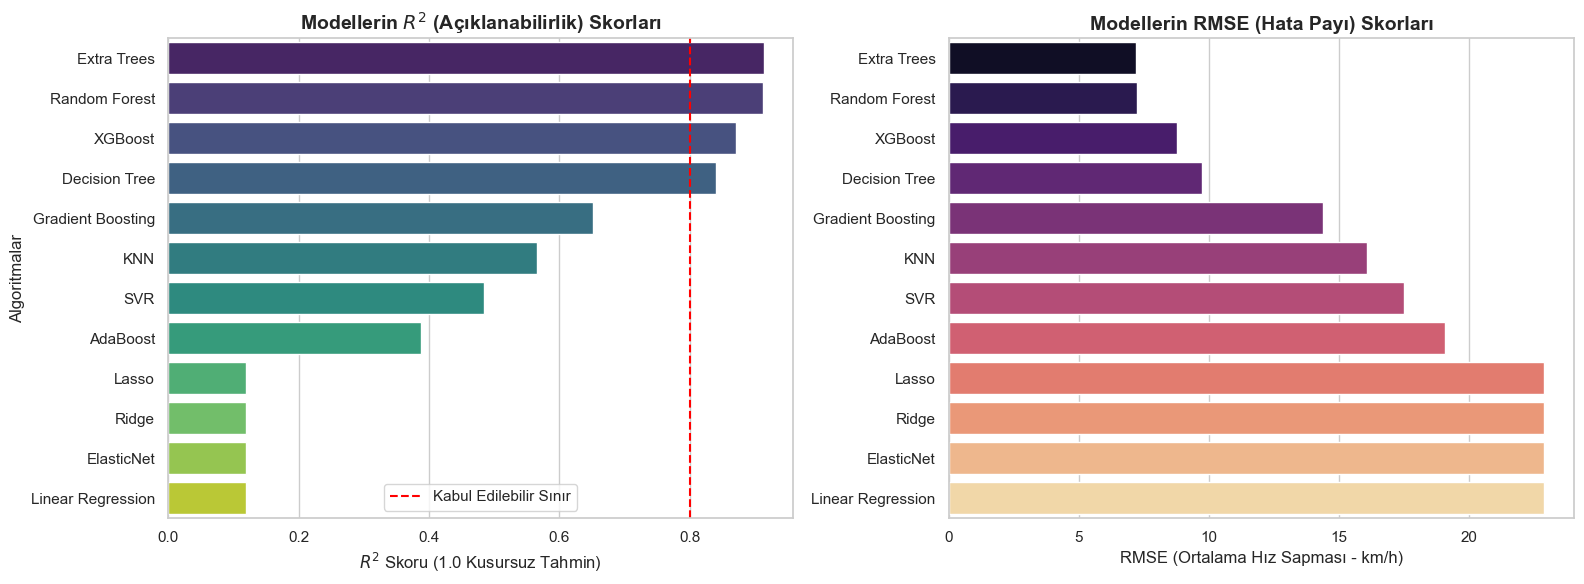

In [19]:
# Görselleştirme Stili
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# 1. Grafik: R2 Skorları (Ne kadar yüksek, o kadar iyi)
plt.subplot(1, 2, 1)
# R2 skoru büyükten küçüğe sıralanıyor
sns.barplot(x='R2_Score', y='Model', data=results_df.sort_values(by='R2_Score', ascending=False), palette='viridis')
plt.title('Modellerin $R^2$ (Açıklanabilirlik) Skorları', fontsize=14, fontweight='bold')
plt.xlabel('$R^2$ Skoru (1.0 Kusursuz Tahmin)')
plt.ylabel('Algoritmalar')
plt.axvline(x=0.8, color='red', linestyle='--', label='Kabul Edilebilir Sınır')
plt.legend()

# 2. Grafik: RMSE Skorları (Ne kadar düşük, o kadar iyi)
plt.subplot(1, 2, 2)
# RMSE skoru küçükten büyüğe sıralanıyor (Hata ne kadar azsa o kadar üstte)
sns.barplot(x='RMSE', y='Model', data=results_df.sort_values(by='RMSE', ascending=True), palette='magma')
plt.title('Modellerin RMSE (Hata Payı) Skorları', fontsize=14, fontweight='bold')
plt.xlabel('RMSE (Ortalama Hız Sapması - km/h)')
plt.ylabel('') # İkinci grafikte y ekseni isimlerini tekrarlamaya gerek yok

plt.tight_layout()
plt.show()

In [20]:
print("\n--- BÜYÜK FİNAL: ŞAMPİYONLAR %100 VERİ İLE EĞİTİLİYOR ---")

# %5'lik zinciri kırıyoruz. X ve y artık tüm veri!
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X, y, test_size=0.2, random_state=42)

# Ölçeklendirme
scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train_final)
X_test_scaled_final = scaler_final.transform(X_test_final)

# Sadece En İyi 3 Modeli Sahaya Sürüyoruz
champion_models = {
    "Extra Trees (Şampiyon)": ExtraTreesRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
}

final_results = []
print("Modeller 1.6 Milyon satırla savaşıyor. Bu işlem 10-30 dakika sürebilir, arkanıza yaslanın...\n")

for name, model in champion_models.items():
    print(f"{name} tüm veriyle eğitiliyor...")
    model.fit(X_train_scaled_final, y_train_final)
    y_pred_final = model.predict(X_test_scaled_final)
    
    final_results.append({
        "Model": name,
        "RMSE": round(np.sqrt(mean_squared_error(y_test_final, y_pred_final)), 3),
        "R2_Score": round(r2_score(y_test_final, y_pred_final), 3)
    })

final_results_df = pd.DataFrame(final_results).sort_values(by='RMSE')
print("\n=== %100 VERİ İLE GERÇEK PERFORMANS RAPORU ===")
print(final_results_df.to_string(index=False))


--- BÜYÜK FİNAL: ŞAMPİYONLAR %100 VERİ İLE EĞİTİLİYOR ---
Modeller 1.6 Milyon satırla savaşıyor. Bu işlem 10-30 dakika sürebilir, arkanıza yaslanın...

Extra Trees (Şampiyon) tüm veriyle eğitiliyor...
Random Forest tüm veriyle eğitiliyor...
XGBoost tüm veriyle eğitiliyor...

=== %100 VERİ İLE GERÇEK PERFORMANS RAPORU ===
                 Model  RMSE  R2_Score
         Random Forest 5.581     0.947
Extra Trees (Şampiyon) 5.953     0.940
               XGBoost 8.498     0.878


C:\Users\ENES\AppData\Local\Temp\ipykernel_15584\287150644.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem Skoru', y='Özellik', data=feature_importance_df, palette='magma')


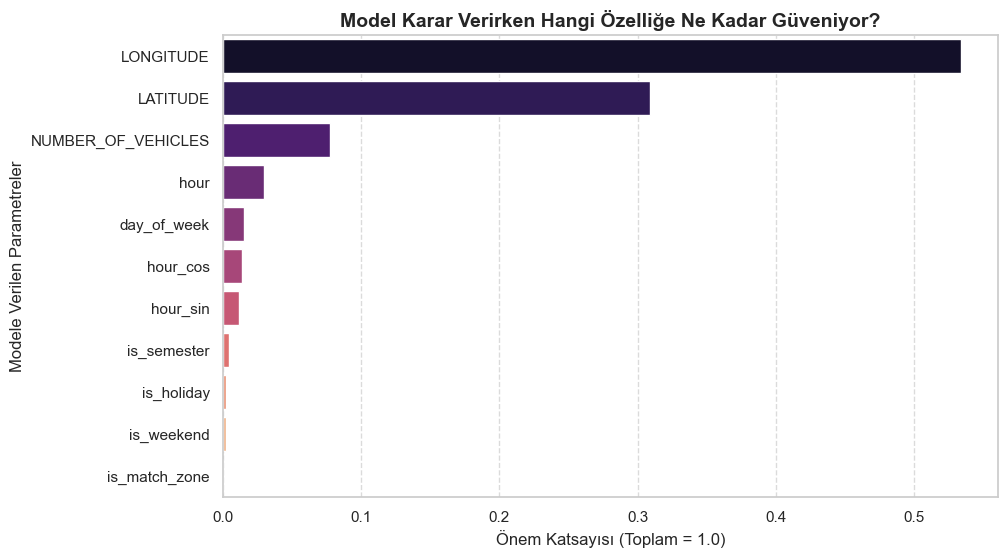

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Şampiyon modeli seçiyoruz (Çünkü daha aşağıdaki hücreye geçmedik)
best_model = champion_models["Random Forest"]

# 2. Özellik Önem Düzeylerini Al
importances = best_model.feature_importances_
feature_names = features # features listesi yukarıda (Aşama 4'te) tanımlanmıştı

# 3. Veriyi Görselleştirme İçin Hazırla
feature_importance_df = pd.DataFrame({
    'Özellik': feature_names,
    'Önem Skoru': importances
}).sort_values(by='Önem Skoru', ascending=False)

# 4. Grafik Çizimi
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Skoru', y='Özellik', data=feature_importance_df, palette='magma')
plt.title('Model Karar Verirken Hangi Özelliğe Ne Kadar Güveniyor?', fontsize=14, fontweight='bold')
plt.xlabel('Önem Katsayısı (Toplam = 1.0)')
plt.ylabel('Modele Verilen Parametreler')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import joblib

# 1. Şampiyon Modeli SIKIŞTIRARAK Kaydet
best_model = champion_models["Random Forest"]

# compress=3 hayat kurtarır, dosyanın fiziksel sınırlarını daraltır.
joblib.dump(best_model, 'istanbul_traffic_rf_model.pkl', compress=3)

# 2. Scaler'ı Kaydet
joblib.dump(scaler_final, 'traffic_scaler.pkl')

print("Operasyon Rasyonel Bir Şekilde Tamamlandı.")
print("Model SIKIŞTIRILARAK ('istanbul_traffic_rf_model.pkl') ve Scaler ('traffic_scaler.pkl') diske kaydedildi.")

Operasyon Başarıyla Tamamlandı.
Model ('istanbul_traffic_rf_model.pkl') ve Scaler ('traffic_scaler.pkl') diskine kaydedildi.
Artık bu modelleri Streamlit dashboard'unda veya bir API'da doğrudan kullanabilirsin.
